In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots prettier
sns.set(style="whitegrid")
%matplotlib inline


In [6]:
# Load dataset
df = pd.read_csv("U.S._Chronic_Disease_Indicators.csv")

# Show the shape and first few rows
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Dataset contains 309215 rows and 34 columns.


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [7]:
# Check data types and missing values
df.info()

# Summary statistics (only numeric columns)
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnote          10

,YearStart,YearEnd,Response,DataValue,DataValueAlt,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,LocationID,ResponseID,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
count,309215.000000,309215.000000,0.0,2.091960e+05,2.091960e+05,188885.000000,188890.000000,0.0,0.0,0.0,0.0,309215.000000,0.0,0.0,0.0,0.0,0.0
mean,2020.012195,2020.288540,NaN,6.943569e+02,7.356701e+02,36.825051,46.030554,NaN,NaN,NaN,NaN,31.208693,NaN,NaN,NaN,NaN,NaN
std,1.530835,1.068591,NaN,1.620341e+04,1.834715e+04,65.025590,69.995643,NaN,NaN,NaN,NaN,17.798773,NaN,NaN,NaN,NaN,NaN
min,2015.000000,2019.000000,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2019.000000,2019.000000,NaN,1.240000e+01,1.240000e+01,9.100000,14.000000,NaN,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,NaN,NaN
50%,2020.000000,2020.000000,NaN,2.700000e+01,2.700000e+01,19.500000,29.200000,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN
75%,2021.000000,2021.000000,NaN,5.780000e+01,5.780000e+01,40.300000,54.300000,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,NaN
max,2022.000000,2022.000000,NaN,2.925456e+06,2.925456e+06,1427.000000,1485.900000,NaN,NaN,NaN,NaN,78.000000,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check for missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


StratificationCategoryID3    309215
Response                     309215
ResponseID                   309215
StratificationCategory2      309215
StratificationID2            309215
StratificationCategoryID2    309215
Stratification3              309215
StratificationCategory3      309215
Stratification2              309215
StratificationID3            309215
DataValueFootnoteSymbol      207499
DataValueFootnote            207499
LowConfidenceLimit           120330
HighConfidenceLimit          120325
DataValueAlt                 100019
DataValue                    100019
Geolocation                    5763
dtype: int64

In [9]:
# Drop rows where DataValue is missing (important for analysis)
df_clean = df.dropna(subset=['DataValue'])

# Convert DataValue to numeric (it may be stored as string)
df_clean['DataValue'] = pd.to_numeric(df_clean['DataValue'], errors='coerce')

# Check again
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 209196 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  209196 non-null  int64  
 1   YearEnd                    209196 non-null  int64  
 2   LocationAbbr               209196 non-null  object 
 3   LocationDesc               209196 non-null  object 
 4   DataSource                 209196 non-null  object 
 5   Topic                      209196 non-null  object 
 6   Question                   209196 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              209196 non-null  object 
 9   DataValueType              209196 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    1697 non-null    object 
 13  DataValueFootnote          1697 no

C:\Users\Kevin\AppData\Local\Temp\ipykernel_11064\3561670874.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['DataValue'] = pd.to_numeric(df_clean['DataValue'], errors='coerce')


In [10]:
# Top 10 questions asked
df_clean['Question'].value_counts().head(10)


Question
Diseases of the heart mortality among all people, underlying cause               4570
Diabetes mortality among all people, underlying or contributing cause            4406
Coronary heart disease mortality among all people, underlying cause              4222
Influenza vaccination among adults                                               4107
No leisure-time physical activity among adults                                   4033
Adults with any disability                                                       4029
Obesity among adults                                                             3973
Average recent physically unhealthy days among adults                            3919
Cerebrovascular disease (stroke) mortality among all people, underlying cause    3897
Depression among adults                                                          3870
Name: count, dtype: int64

In [11]:
# Unique locations and stratifications
print("States:", df_clean['LocationDesc'].nunique())
print("Stratifications:", df_clean['StratificationCategory1'].unique())


States: 55
Stratifications: ['Sex' 'Overall' 'Race/Ethnicity' 'Age' 'Grade']


C:\Users\Kevin\AppData\Local\Temp\ipykernel_11064\174984388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_means.values, y=topic_means.index, palette="viridis")


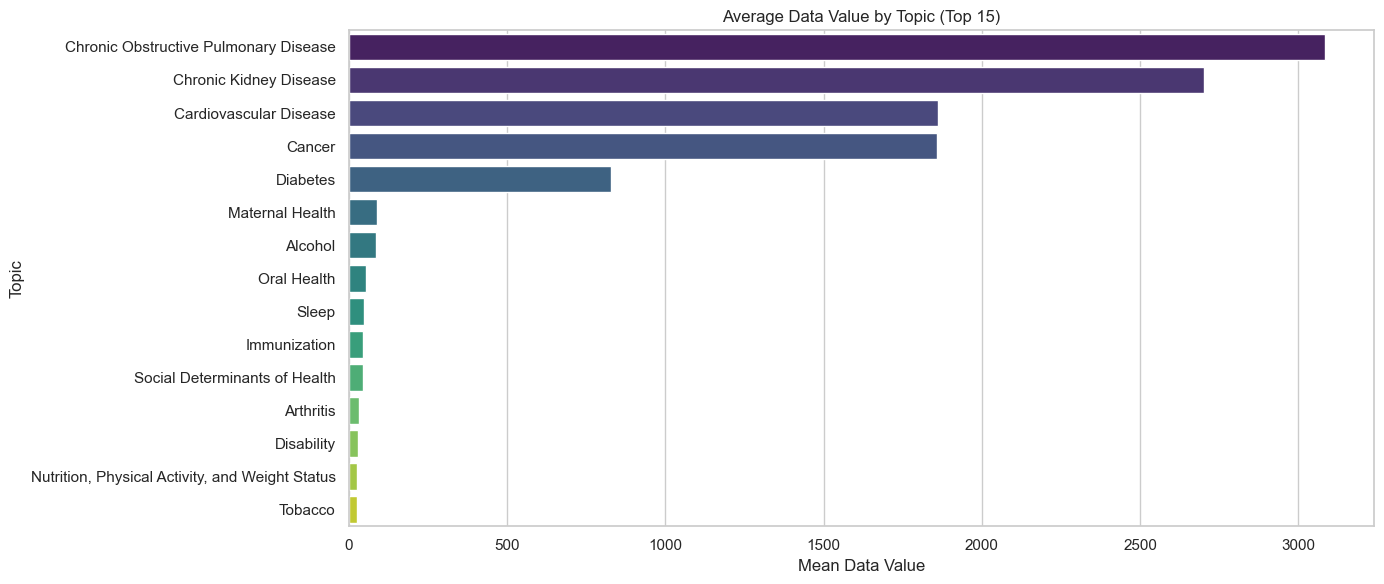

In [12]:
plt.figure(figsize=(14,6))
topic_means = df_clean.groupby('Topic')['DataValue'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=topic_means.values, y=topic_means.index, palette="viridis")
plt.title("Average Data Value by Topic (Top 15)")
plt.xlabel("Mean Data Value")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()
